## Sommaire
Navigation rapide vers les sections du notebook.

- [Partie 1 - Regression logistique multiclasse basique](#partie-1---regression-logistique-multiclasse-basique)
- [Partie 2 - Limitation de l eparpillement des classes](#partie-2---limitation-de-l-eparpillement-des-classes)
- [Partie 3 - Regression logistique avec balanced](#partie-3---regression-logistique-avec-balanced)
- [Partie 4 - Regression logistique avec CV en 5 folds](#partie-4---regression-logistique-avec-cv-en-5-folds)
- [Partie 5 - RN basique sans optimisation](#partie-5---rn-basique-sans-optimisation)

In [193]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier



In [194]:
df = pd.read_csv(r"c:\Users\AsgharAli Thomas\Documents\RFID2\DS.csv")
df.shape

(4411, 160)

On introduit les variables x, y, z. On fait via str split

In [195]:
if "xyz" in df.columns:
    xyz_split = df["xyz"].astype(str).str.split("__", expand=True)
    if xyz_split.shape[1] >= 3:
        df[["x", "y", "z"]] = xyz_split.iloc[:, :3]

required = ["x", "y", "z"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Colonnes manquantes dans df: {missing}")

for c in required:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=required).copy()
df = df.reset_index(drop=True)

print("Shape df:", df.shape)
df[["x", "y", "z"]].head()

Shape df: (4411, 160)


,x,y,z
0,1.82,2.51,0.05
1,10.10,3.82,1.29
2,10.34,3.33,0.05
3,10.51,3.26,0.05
4,10.71,3.92,1.57


On veut maintenant, crées des voxels de taille 1 en 3D. x-> i, y-> j, z-> k
ici les classes n'ont pas de sens, mais en baseline on peut tester pour voir les resultats que cela peut donner.


In [196]:
col = X.columns[0]
for i in col :
    if i=="polar":
        print("ERREUR")

In [197]:
import numpy as np
import pandas as pd
### voxels
h = 1  # taille du voxel

for c in ["x", "y", "z"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["x", "y", "z"]).copy()

df["i"] = np.floor(df["x"] / h).astype(int)
df["j"] = np.floor(df["y"] / h).astype(int)
df["k"] = np.floor(df["z"] / h).astype(int)

Nx = df["i"].max() + 1 # nombres de voxels en x, y, z
Ny = df["j"].max() + 1
Nk = df["k"].max() + 1

df["class_id"] = df["i"] + Nx * df["j"] + Nx * Ny * df["k"]
target = df["class_id"]
### voxels

X = df.drop(columns=[
    "i", "j", "k", "class_id", "x", "y", "z", "xyz",
    "polar", "nearestAnt",
    "D_041A9F60", "D_041A9F61", "D_0F17B312", "D_0F17B313",
    "D_PORT_1", "D_PORT_2", "D_PORT_3", "D_PORT_4",
    "D_nearestAnt", "nearestD",
], errors="ignore")

# Retirer toutes les colonnes non numeriques pour eviter l erreur du scaler
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
X = X.drop(columns=non_numeric_cols, errors="ignore")


# Anti-fuite: ne garder que les vraies features RSSI
rssi_cols = [c for c in df.columns if c.startswith("max__Delta_rssi")]
if not rssi_cols:
    raise ValueError("Aucune colonne RSSI trouvee (prefixe max__Delta_rssi)")

X_small = df[rssi_cols].copy()

print("Nombre de classes :", target.nunique())
print("Nombre final de features RSSI :", X.shape[1])
print("Nombre de features RSSI selectionnees :", X_small.shape[1])

Nombre de classes : 74
Nombre final de features RSSI : 144
Nombre de features RSSI selectionnees : 24


In [198]:
df['class_id'].nunique()

74

Nombre de classes: 74
Min/Max par classe: 10 / 160
Ratio de disparite (max/min): 16.00
Coefficient de variation: 0.587


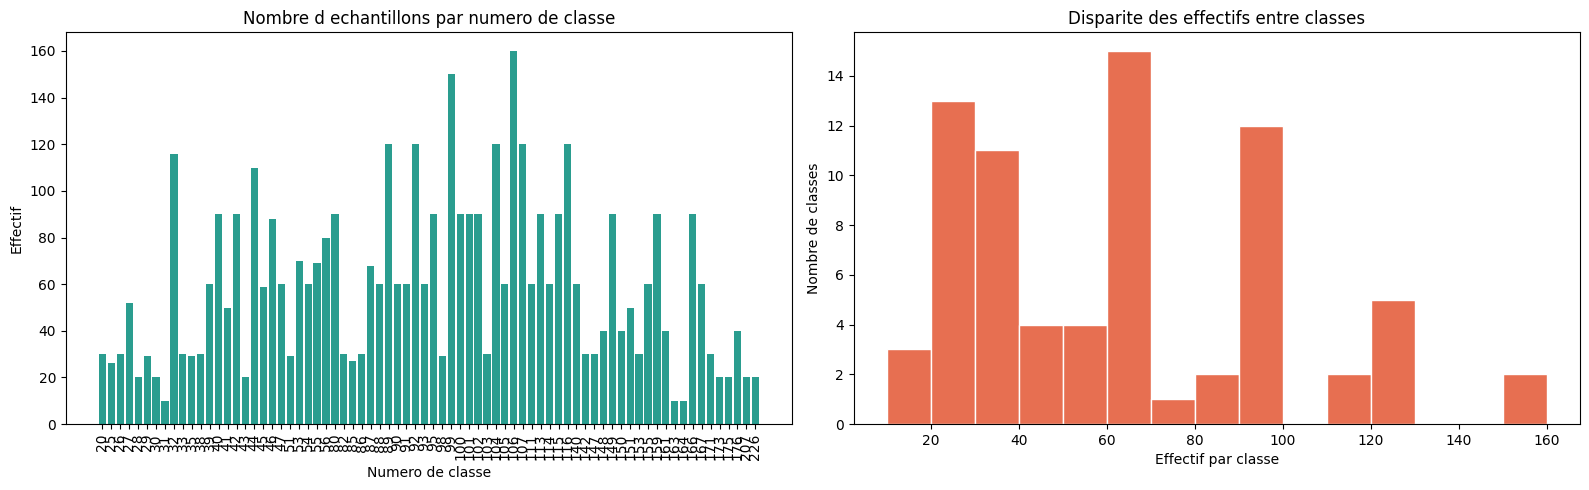

In [199]:
import matplotlib.pyplot as plt

class_counts = target.value_counts().sort_index()

min_count = int(class_counts.min())
max_count = int(class_counts.max())
mean_count = float(class_counts.mean())
std_count = float(class_counts.std(ddof=0))
imbalance_ratio = max_count / max(min_count, 1)
cv = std_count / mean_count if mean_count > 0 else np.nan

print(f"Nombre de classes: {class_counts.shape[0]}")
print(f"Min/Max par classe: {min_count} / {max_count}")
print(f"Ratio de disparite (max/min): {imbalance_ratio:.2f}")
print(f"Coefficient de variation: {cv:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(class_counts.index.astype(str), class_counts.values, color="#2a9d8f")
axes[0].set_title("Nombre d echantillons par numero de classe")
axes[0].set_xlabel("Numero de classe")
axes[0].set_ylabel("Effectif")
axes[0].tick_params(axis="x", labelrotation=90)

axes[1].hist(class_counts.values, bins=15, color="#e76f51", edgecolor="white")
axes[1].set_title("Disparite des effectifs entre classes")
axes[1].set_xlabel("Effectif par classe")
axes[1].set_ylabel("Nombre de classes")

plt.tight_layout()
plt.show()

Pour l'instant on fait une classif basique mais on pourrait aussi essayer en normalisant standars scaler ne regle pas le desiquilibre de classe. Donc deuxieme pîste d'amélioratino


In [200]:
# Verification: class_id est cree a partir de la position voxel (i, j, k)
check_cols = ["xyz","x", "y", "z", "i", "j", "k", "class_id"]
display(df[check_cols].head(10))

labels_uniques = np.sort(df["class_id"].unique())
print("Nombre de labels uniques:", len(labels_uniques))
print("Premiers labels tries:", labels_uniques[:10])



,xyz,x,y,z,i,j,k,class_id
0,1.82__2.51__0.05,1.82,2.51,0.05,1,2,0,25
1,10.1__3.82__1.29,10.10,3.82,1.29,10,3,1,106
2,10.34__3.33__0.05,10.34,3.33,0.05,10,3,0,46
3,10.51__3.26__0.05,10.51,3.26,0.05,10,3,0,46
4,10.71__3.92__1.57,10.71,3.92,1.57,10,3,1,106
5,10.72__3.5__0.05,10.72,3.50,0.05,10,3,0,46
6,10.79__3.89__1.57,10.79,3.89,1.57,10,3,1,106
7,10.98__1.98__1.1300000000000001,10.98,1.98,1.13,10,1,1,82
8,11.01__3.87__1.08,11.01,3.87,1.08,11,3,1,107
9,11.16__3.95__1.07,11.16,3.95,1.07,11,3,1,107


Nombre de labels uniques: 74
Premiers labels tries: [20 25 26 27 28 29 30 31 32 33]


In [201]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)


print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (3528, 144)
Test: (883, 144)


In [202]:
from sklearn.model_selection import GroupShuffleSplit

# Anti-fuite: on separe par groupe de position xyz
groups = df.loc[X_small.index, "xyz"].astype(str) if "xyz" in df.columns else df.loc[X.index].index.astype(str)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_small, target, groups=groups))

X_train_small, X_test_small = X_small.iloc[train_idx], X_small.iloc[test_idx]
y_train_small, y_test_small = target.iloc[train_idx], target.iloc[test_idx]

print("Train:", X_train_small.shape)
print("Test:", X_test_small.shape)
print("Groupes train:", groups.iloc[train_idx].nunique())
print("Groupes test:", groups.iloc[test_idx].nunique())

Train: (3529, 24)
Test: (882, 24)
Groupes train: 355
Groupes test: 89


In [203]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_features = X_train_scaled.shape[1]
num_classes = target.nunique()

print("num_features =", num_features)
print("num_classes =", num_classes)

num_features = 144
num_classes = 74


## Partie 1 - Regression logistique multiclasse basique
Modele baseline.

In [204]:
from sklearn.linear_model import LogisticRegression

RLog = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

RLog.fit(X_train_scaled, y_train)

y_pred = RLog.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred)

print("Logistic Regression accuracy:", acc_lr)

Logistic Regression accuracy: 0.23442808607021517


In [205]:
def decode_class_id(class_id, Nx, Ny):
    k = class_id // (Nx * Ny)
    remainder = class_id % (Nx * Ny)

    j = remainder // Nx
    i = remainder % Nx

    return i, j, k

In [206]:

def voxel_center(class_id, Nx, Ny, h):
    i, j, k = decode_class_id(class_id, Nx, Ny)

    x = (i + 0.5) * h
    y = (j + 0.5) * h
    z = (k + 0.5) * h

    return np.array([x, y, z])

In [207]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

errors = []
predA3 = []
xyz_test = []
for pred_id, true_xyz in zip(y_pred, true_coords):

    pred_xyz = voxel_center(pred_id, Nx, Ny, h)

    err = np.linalg.norm(true_xyz - pred_xyz)

    errors.append(err)
    predA3.append(pred_xyz)
    xyz_test.append(true_xyz)
errors = np.array(errors)

print("Erreur moyenne :", errors.mean())
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 1.3964125171740915
Erreur mediane : 1.2310158406779337
Erreur max : 7.302800832557328


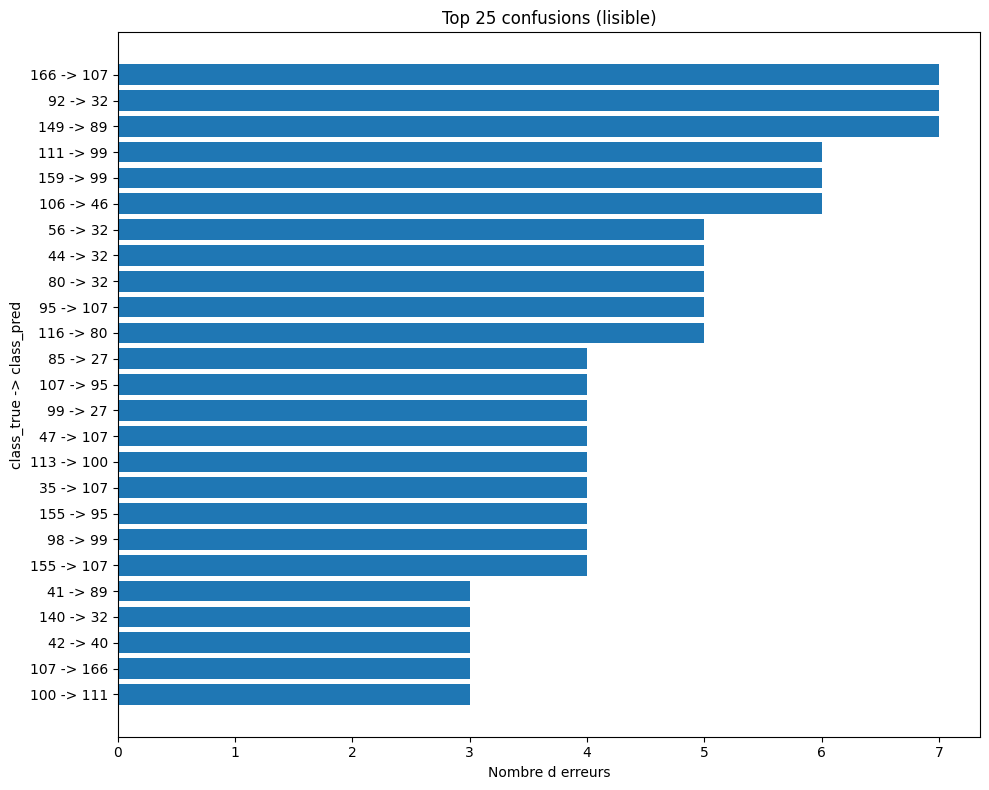

In [208]:
y_true = np.asarray(y_test).astype(int)
y_hat = np.asarray(y_pred).astype(int)

if y_true.shape[0] != y_hat.shape[0]:
    raise ValueError("y_test et y_pred n ont pas la meme taille.")

class_errors = pd.DataFrame({
    "class_true": y_true,
    "class_pred": y_hat,
})
class_errors = class_errors[class_errors["class_true"] != class_errors["class_pred"]].copy()

if class_errors.empty:
    print("Aucune erreur de class_id a afficher.")
else:
    confusion_err = (
        class_errors.groupby(["class_true", "class_pred"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    # 1) Top confusions en barres horizontales (plus lisible)
    top_n = 25
    top_err = confusion_err.head(top_n).copy()
    top_err["pair"] = top_err["class_true"].astype(str) + " -> " + top_err["class_pred"].astype(str)
    top_err = top_err.sort_values("count", ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(top_err["pair"], top_err["count"])
    plt.title(f"Top {top_n} confusions (lisible)")
    plt.xlabel("Nombre d erreurs")
    plt.ylabel("class_true -> class_pred")
    plt.tight_layout()
    plt.show()

In [209]:
rows_diff = []

for class_true, class_pred, xyz_true, xyz_pred in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred).astype(int),
    xyz_test,
    predA3
):

    dx = float(xyz_pred[0] - xyz_true[0])
    dy = float(xyz_pred[1] - xyz_true[1])
    dz = float(xyz_pred[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))  # distance 3D

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred": int(class_pred),

        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),

        "x_pred": float(xyz_pred[0]),
        "y_pred": float(xyz_pred[1]),
        "z_pred": float(xyz_pred[2]),

        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff))

# erreurs > 1 m
df_diff_1m = df_diff[df_diff["distance"] > 1]

print("Nombre d'erreurs > 1 m:", len(df_diff_1m))

display(df_diff_1m.head(20))

print(df_diff_1m[[
    "class_id_true",
    "class_id_pred",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d'erreurs > 1 m: 543


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
0,91,32,7.86,2.99,1.10,8.5,2.5,0.5,0.64,-0.49,-0.60,1.004838
1,105,45,9.30,3.70,1.67,9.5,3.5,0.5,0.20,-0.20,-1.17,1.203703
3,100,113,4.52,3.67,1.34,5.5,4.5,1.5,0.98,0.83,0.16,1.294179
4,53,55,5.55,4.09,0.42,7.5,4.5,0.5,1.95,0.41,0.08,1.994242
7,101,111,5.04,3.83,1.05,3.5,4.5,1.5,-1.54,0.67,0.45,1.738678
8,93,45,9.57,2.71,1.96,9.5,3.5,0.5,-0.07,0.79,-1.46,1.661505
9,114,161,6.55,4.02,1.86,5.5,3.5,2.5,-1.05,-0.52,0.64,1.335103
10,47,107,11.23,3.36,0.37,11.5,3.5,1.5,0.27,0.14,1.13,1.170214
11,111,99,3.20,4.47,1.67,3.5,3.5,1.5,0.30,-0.97,-0.17,1.029466
12,151,116,7.86,2.99,2.40,8.5,4.5,1.5,0.64,1.51,-0.90,1.870749


       class_id_true  class_id_pred          dx          dy          dz  \
count     543.000000     543.000000  543.000000  543.000000  543.000000   
mean       97.082873      86.279926   -0.082265   -0.140663   -0.075175   
std        44.841238      40.873837    1.461855    1.078447    0.986929   
min        20.000000      20.000000   -7.220000   -3.020000   -3.040000   
25%        53.500000      45.000000   -0.910000   -0.950000   -0.840000   
50%        99.000000      92.000000    0.070000   -0.060000   -0.100000   
75%       116.000000     107.000000    0.850000    0.680000    0.625000   
max       226.000000     176.000000    4.300000    2.980000    2.450000   

         distance  
count  543.000000  
mean     1.902407  
std      0.824942  
min      1.001199  
25%      1.328439  
50%      1.685052  
75%      2.256079  
max      7.302801  


faudrait dig sur pq cette data donne ces erreurs maisjsp cmt faire 

On réessaie le même modèle mais cette fois ci avec X small


In [210]:
scaler = StandardScaler()

X_train_small_scaled = scaler.fit_transform(X_train_small)
X_test_small_scaled = scaler.transform(X_test_small)

num_features = X_train_small_scaled.shape[1]
num_classes = target.nunique()

print("num_features =", num_features)
print("num_classes =", num_classes)

num_features = 24
num_classes = 74


In [211]:
from sklearn.linear_model import LogisticRegression

RLog = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

RLog.fit(X_train_small_scaled, y_train_small)

y_pred = RLog.predict(X_test_small_scaled)
acc_lr = accuracy_score(y_test_small, y_pred)

print("Logistic Regression accuracy:", acc_lr)

Logistic Regression accuracy: 0.11791383219954649


aucun interet de continuer au vu de l'accuracy je pense.

## Partie 2 - Limitation de l eparpillement des classes
Reduction des classes surrepresentees; impact faible observe.

In [212]:
# Proportion de chaque class_id dans un DataFrame
df_prop_class = (
    df["class_id"]
    .value_counts()
    .rename_axis("class_id")
    .reset_index()
    .sort_values("class_id")
    .reset_index(drop=True)
)

print("Nombre de classes:", df_prop_class.shape[0])

display(df_prop_class.max())
mean = df_prop_class["class_id"].mean()
print("Moyenne:", mean)


Nombre de classes: 74


class_id    226
count       160
dtype: int64

Moyenne: 96.01351351351352


In [213]:
df_prop_class = (
    df["class_id"]
    .value_counts()
    .rename_axis("class_id")
    .reset_index(name="count")
)

print("Nombre de classes:", df_prop_class.shape[0])

# afficher les classes les plus représentées
display(df_prop_class.sort_values("count", ascending=True).head(20))

Nombre de classes: 74


,class_id,count
72,163,10
73,164,10
71,31,10
65,43,20
64,30,20
66,173,20
68,207,20
67,28,20
69,226,20
70,175,20


## Partie 3 - Regression logistique avec balanced
Test avec class_weight="balanced" pour compenser le desequilibre.

In [214]:
from sklearn.linear_model import LogisticRegression

RLog_balenced = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)

RLog_balenced.fit(X_train_scaled, y_train)

y_pred_balenced = RLog_balenced.predict(X_test_scaled)
acc_lr_balenced = accuracy_score(y_test, y_pred_balenced)

print("Logistic Regression accuracy:", acc_lr_balenced)

Logistic Regression accuracy: 0.2129105322763307


etonnament l'accuracy descends ... néanmoins ce n'est pas une metrics fiable on va tester d'avantage.


In [215]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

errors = []
predA3_balenced = []
xyz_test_balenced = []
for pred_id, true_xyz in zip(y_pred_balenced, true_coords):

    pred_xyz_balenced = voxel_center(pred_id, Nx, Ny, h)

    err = np.linalg.norm(true_xyz - pred_xyz_balenced)

    errors.append(err)
    predA3_balenced.append(pred_xyz_balenced)
    xyz_test_balenced.append(true_xyz)
errors = np.array(errors)

print("Erreur moyenne :", errors.mean())
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 1.529969178330875
Erreur mediane : 1.3351029922818685
Erreur max : 9.284982498637248


In [216]:
rows_diff = []

for class_true, class_pred, xyz_true, xyz_pred_balenced in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred_balenced).astype(int),
    xyz_test_balenced,
    predA3_balenced
):
    dx = float(xyz_pred_balenced[0] - xyz_true[0])
    dy = float(xyz_pred_balenced[1] - xyz_true[1])
    dz = float(xyz_pred_balenced[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred": int(class_pred),
        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),
        "x_pred": float(xyz_pred_balenced[0]),
        "y_pred": float(xyz_pred_balenced[1]),
        "z_pred": float(xyz_pred_balenced[2]),
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff_balenced = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff_balenced))

df_diff_balenced_1p7m = df_diff_balenced[df_diff_balenced["distance"] > 3]
print("Nombre d erreurs > 1.7 m:", len(df_diff_balenced_1p7m))

display(df_diff_balenced_1p7m.head(20))

print(df_diff_balenced_1p7m[[
    "class_id_true",
    "class_id_pred",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d erreurs > 1.7 m: 61


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
54,29,25,5.44,2.66,0.05,1.5,2.5,0.5,-3.94,-0.16,0.45,3.968841
59,56,80,8.56,4.52,0.83,8.5,1.5,1.5,-0.06,-3.02,0.67,3.094010
61,90,153,6.31,2.75,1.77,9.5,2.5,2.5,3.19,-0.25,0.73,3.281996
62,32,47,8.56,2.48,0.70,11.5,3.5,0.5,2.94,1.02,-0.20,3.118333
80,101,207,5.69,3.07,1.39,3.5,2.5,3.5,-2.19,-0.57,2.11,3.094043
86,46,55,10.34,3.33,0.05,7.5,4.5,0.5,-2.84,1.17,0.45,3.104352
109,95,32,11.19,2.26,1.88,8.5,2.5,0.5,-2.69,0.24,-1.38,3.032837
143,116,80,8.56,4.52,1.80,8.5,1.5,1.5,-0.06,-3.02,-0.30,3.035457
180,32,25,8.43,2.41,0.05,1.5,2.5,0.5,-6.93,0.09,0.45,6.945178
183,159,33,3.32,3.60,2.49,9.5,2.5,0.5,6.18,-1.10,-1.99,6.585021


       class_id_true  class_id_pred         dx         dy         dz  \
count      61.000000      61.000000  61.000000  61.000000  61.000000   
mean       83.426230      78.295082  -1.560984  -0.838197   0.228852   
std        45.812465      61.500771   3.431041   1.318075   1.317581   
min        25.000000      20.000000  -9.220000  -3.020000  -3.040000   
25%        42.000000      26.000000  -3.400000  -1.470000  -0.300000   
50%        90.000000      55.000000  -2.660000  -0.860000   0.350000   
75%       116.000000     140.000000   1.100000  -0.160000   0.510000   
max       207.000000     207.000000   6.180000   2.980000   3.450000   

        distance  
count  61.000000  
mean    4.018771  
std     1.438925  
min     3.014996  
25%     3.089741  
50%     3.360327  
75%     4.416492  
max     9.284982  


on observe pas des résultat proprement meilleurs, néanmoins on peut également tester d'autre méthode.

## Partie 4 - Regression logistique avec CV en 5 folds
Evaluation par validation croisee (5 folds).

In [217]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

RLog_cv = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    random_state=53
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RLog_cv, X_train, y_train, cv=cv)

print("CV accuracy scores:", cv_scores)
print("CV mean accuracy:", cv_scores.mean())

# entrainement final
RLog_cv.fit(X_train, y_train)

y_pred_cv = RLog_cv.predict(X_test)
acc_lr_cv = accuracy_score(y_test, y_pred_cv)

print("Test accuracy:", acc_lr_cv)

CV accuracy scores: [0.20538244 0.19830028 0.22096317 0.19432624 0.19574468]
CV mean accuracy: 0.20294336286741807
Test accuracy: 0.22989807474518686


In [219]:
coef_df = pd.DataFrame(
    RLog_cv.coef_,
    columns=X_train.columns
)
coef_df.max()

max__Delta_rssi__24.0__041A9F60__NONE    0.432237
max__Delta_rssi__24.0__041A9F61__NONE    0.658334
max__Delta_rssi__24.0__0F173B12__NONE    1.440433
max__Delta_rssi__24.0__0F173B13__NONE    0.843061
max__Delta_rssi__24.0__PORT_1__NONE      1.074433
                                           ...   
min__rssi2__31.5__0F173B13__NONE         0.775312
min__rssi2__31.5__PORT_1__NONE           0.877909
min__rssi2__31.5__PORT_2__NONE           1.135170
min__rssi2__31.5__PORT_3__NONE           0.784360
min__rssi2__31.5__PORT_4__NONE           0.855285
Length: 144, dtype: float64

In [220]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

errors = []
predA3_cv = []
xyz_test_cv = []
for pred_id, true_xyz in zip(y_pred_cv, true_coords):

    pred_xyz_cv = voxel_center(pred_id, Nx, Ny, h)

    err = np.linalg.norm(true_xyz - pred_xyz_cv)

    errors.append(err)
    predA3_cv.append(pred_xyz_cv)
    xyz_test_cv.append(true_xyz)
errors = np.array(errors)
rmse_cv = float(np.sqrt(np.mean(errors ** 2)))

print("Erreur moyenne :", errors.mean())
print("RMSE :", rmse_cv)
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 1.4165337390435704
RMSE : 1.7774357699210372
Erreur mediane : 1.193859288191033
Erreur max : 7.957047191012505


lerreur max descend de 5 a 3 ? positif :)


In [221]:
rows_diff = []

for class_true, class_pred, xyz_true, xyz_pred_cv in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred_cv).astype(int),
    xyz_test_cv,
    predA3_cv
):
    dx = float(xyz_pred_cv[0] - xyz_true[0])
    dy = float(xyz_pred_cv[1] - xyz_true[1])
    dz = float(xyz_pred_cv[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred": int(class_pred),
        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),
        "x_pred": float(xyz_pred_cv[0]),
        "y_pred": float(xyz_pred_cv[1]),
        "z_pred": float(xyz_pred_cv[2]),
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff_cv = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff_cv))

df_diff_cv_1p3m = df_diff_cv[df_diff_cv["distance"] > 2]
print("Nombre d erreurs > 1.3 m:", len(df_diff_cv_1p3m))

display(df_diff_cv_1p3m.head(20))

print(df_diff_cv_1p3m[[
    "class_id_true",
    "class_id_pred",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d erreurs > 1.3 m: 180


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
15,53,90,5.55,4.09,0.42,6.5,2.5,1.5,0.95,-1.59,1.08,2.144062
16,90,40,6.34,2.69,1.43,4.5,3.5,0.5,-1.84,0.81,-0.93,2.215085
26,102,40,6.83,3.36,1.67,4.5,3.5,0.5,-2.33,0.14,-1.17,2.611015
28,88,114,4.41,2.39,1.71,6.5,4.5,1.5,2.09,2.11,-0.21,2.977297
38,176,107,8.56,4.52,2.12,11.5,3.5,1.5,2.94,-1.02,-0.62,3.173074
48,151,32,7.40,2.87,2.84,8.5,2.5,0.5,1.10,-0.37,-2.34,2.611992
51,149,99,5.67,2.44,2.22,3.5,3.5,1.5,-2.17,1.06,-0.72,2.520099
52,56,32,8.87,4.79,0.05,8.5,2.5,0.5,-0.37,-2.29,0.45,2.362943
55,20,116,8.57,1.92,0.80,8.5,4.5,1.5,-0.07,2.58,0.70,2.674191
59,56,80,8.56,4.52,0.83,8.5,1.5,1.5,-0.06,-3.02,0.67,3.094010


       class_id_true  class_id_pred          dx          dy          dz  \
count     180.000000     180.000000  180.000000  180.000000  180.000000   
mean       96.005556      74.833333   -0.802889   -0.385833   -0.176167   
std        46.587995      41.985033    2.652001    1.265407    1.074303   
min        20.000000      20.000000   -7.730000   -3.020000   -3.040000   
25%        54.750000      32.000000   -2.525000   -1.297500   -0.950000   
50%       100.500000      83.500000   -0.330000   -0.325000   -0.205000   
75%       116.000000     103.000000    1.630000    0.585000    0.480000   
max       207.000000     207.000000    3.950000    2.980000    2.450000   

         distance  
count  180.000000  
mean     2.998676  
std      1.255124  
min      2.003522  
25%      2.226448  
50%      2.589728  
75%      3.214886  
max      7.957047  


In [222]:
print(*X_train.columns, sep="\n")

max__Delta_rssi__24.0__041A9F60__NONE
max__Delta_rssi__24.0__041A9F61__NONE
max__Delta_rssi__24.0__0F173B12__NONE
max__Delta_rssi__24.0__0F173B13__NONE
max__Delta_rssi__24.0__PORT_1__NONE
max__Delta_rssi__24.0__PORT_2__NONE
max__Delta_rssi__24.0__PORT_3__NONE
max__Delta_rssi__24.0__PORT_4__NONE
max__Delta_rssi__27.0__041A9F60__NONE
max__Delta_rssi__27.0__041A9F61__NONE
max__Delta_rssi__27.0__0F173B12__NONE
max__Delta_rssi__27.0__0F173B13__NONE
max__Delta_rssi__27.0__PORT_1__NONE
max__Delta_rssi__27.0__PORT_2__NONE
max__Delta_rssi__27.0__PORT_3__NONE
max__Delta_rssi__27.0__PORT_4__NONE
max__Delta_rssi__31.5__041A9F60__NONE
max__Delta_rssi__31.5__041A9F61__NONE
max__Delta_rssi__31.5__0F173B12__NONE
max__Delta_rssi__31.5__0F173B13__NONE
max__Delta_rssi__31.5__PORT_1__NONE
max__Delta_rssi__31.5__PORT_2__NONE
max__Delta_rssi__31.5__PORT_3__NONE
max__Delta_rssi__31.5__PORT_4__NONE
max__rssi1__24.0__041A9F60__NONE
max__rssi1__24.0__041A9F61__NONE
max__rssi1__24.0__0F173B12__NONE
max__rssi1__2

### Moyenne des probabilités pour améliorer la localisation

Actuellement, le modèle prédit un **voxel** via une régression logistique multinomiale.  
La position \((x,y,z)\) est ensuite obtenue en prenant **le centre du voxel le plus probable (argmax)**.

Cependant, l’argmax utilise uniquement la classe la plus probable et **ignore l’information contenue dans le reste de la distribution de probabilités**.

L’idée est donc d’utiliser les probabilités prédites pour calculer **une moyenne pondérée des centres des voxels** :

$$
(\hat{x}, \hat{y}, \hat{z}) = \sum_{k} p_k \,(x_k, y_k, z_k)
$$

où :

- $p_k$ est la probabilité prédite pour le voxel $k$
- $(x_k, y_k, z_k)$ est le centre du voxel $k$

Cette approche permet de **réduire l’erreur de discrétisation liée aux voxels**.  
Si le modèle hésite entre plusieurs voxels voisins, la moyenne pondérée permet de prédire une position **intermédiaire**, souvent plus proche de la position réelle que celle obtenue avec l’argmax.

In [223]:
RLog_cv_mean = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    random_state=53
)

folds = KFold(n_splits=8, shuffle=True, random_state=42)
cv_scores_mean = cross_val_score(RLog_cv, X_train_scaled, y_train, cv=folds)

print("CV accuracy scores:", cv_scores_mean)
print("CV mean accuracy:", cv_scores_mean.mean())

# entraînement final
RLog_cv_mean.fit(X_train_scaled, y_train)

distrib_proba = RLog_cv_mean.predict_proba(X_test_scaled)




CV accuracy scores: [0.18594104 0.20861678 0.17687075 0.20181406 0.23129252 0.20861678
 0.17687075 0.20181406]
CV mean accuracy: 0.1989795918367347


In [224]:
classes = RLog_cv_mean.classes_.astype(float)   # ex: [0, 1, 2, ...] ou labels réels
classes.shape

(74,)

In [225]:
distrib_proba[1].shape

(74,)

In [226]:
y_pred_cv_mean = []
n = len(distrib_proba)

for i in range(n):
    a = np.sum(distrib_proba[i] * classes)
    y_pred_cv_mean.append(a)

centers = np.array([voxel_center(int(c), Nx, Ny, h) for c in classes], dtype=float) # on construit la table des centres de chaques voxels
predA3_cv_mean = distrib_proba @ centers # on fait le produit matriciel entre les proba et les centres pour obtenir la position prédite en continu (non discrète)


predA3_cv_mean.shape


(883, 3)

In [227]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy(dtype=float)


errors = np.linalg.norm(true_coords - predA3_cv_mean, axis=1)

print("Erreur moyenne :", errors.mean())
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 1.2273310682339376
Erreur mediane : 1.1225686208837753
Erreur max : 6.162361228497757


In [228]:
rows_diff = []

for class_true, class_pred_mean, xyz_true, xyz_pred_cv_mean in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred_cv_mean, dtype=float),
    xyz_test,
    predA3_cv_mean
):
    dx = float(xyz_pred_cv_mean[0] - xyz_true[0])
    dy = float(xyz_pred_cv_mean[1] - xyz_true[1])
    dz = float(xyz_pred_cv_mean[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred_mean": float(class_pred_mean),
        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),
        "x_pred": float(xyz_pred_cv_mean[0]),
        "y_pred": float(xyz_pred_cv_mean[1]),
        "z_pred": float(xyz_pred_cv_mean[2]),
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff_cv_mean = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff_cv_mean))

df_diff_cv_mean_1m = df_diff_cv_mean[df_diff_cv_mean["distance"] > 2]
print("Nombre d erreurs > 1 m:", len(df_diff_cv_mean_1m))

display(df_diff_cv_mean_1m.head(20))

print(df_diff_cv_mean_1m[[
    "class_id_true",
    "class_id_pred_mean",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d erreurs > 1 m: 101


,class_id_true,class_id_pred_mean,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
13,46,91.819377,10.51,3.26,0.37,8.162112,3.117042,1.379213,-2.347888,-0.142958,1.009213,2.559595
27,25,75.333972,1.82,2.51,0.37,4.704203,3.115030,1.162490,2.884203,0.605030,0.792490,3.051676
38,176,108.428504,8.56,4.52,2.12,9.897930,3.076052,1.635299,1.337930,-1.443948,-0.484701,2.027308
43,140,165.639547,8.52,1.93,2.13,8.528774,4.127412,2.401364,0.008774,2.197412,0.271364,2.214122
47,46,157.439931,10.51,3.26,0.05,11.390662,3.498560,2.342776,0.880662,0.238560,2.292776,2.467650
55,20,117.020575,8.57,1.92,0.80,8.500000,4.461331,1.524743,-0.070000,2.541331,0.724743,2.643580
59,56,84.141065,8.56,4.52,0.83,8.500033,1.851743,1.498669,-0.059967,-2.668257,0.668669,2.751419
61,90,153.037506,6.31,2.75,1.77,9.084236,2.628361,2.481882,2.774236,-0.121639,0.711882,2.866698
65,56,32.077081,8.56,4.52,0.83,8.500009,2.496300,0.502024,-0.059991,-2.023700,-0.327976,2.050982
91,85,63.335187,1.82,2.51,1.02,4.571292,2.849088,1.017914,2.751292,0.339088,-0.002086,2.772110


       class_id_true  class_id_pred_mean          dx          dy          dz  \
count     101.000000          101.000000  101.000000  101.000000  101.000000   
mean       93.752475           87.436901    0.164792   -0.135952    0.020740   
std        50.766998           26.582415    2.190214    1.132511    1.003506   
min        20.000000           20.049456   -6.012809   -3.018920   -2.426267   
25%        46.000000           69.660006   -2.047201   -0.898284   -0.725429   
50%        92.000000           80.532278    0.139360    0.090107    0.076994   
75%       140.000000           97.937830    2.014691    0.609304    0.730874   
max       207.000000          165.639547    4.330348    2.541331    2.292776   

         distance  
count  101.000000  
mean     2.593149  
std      0.584389  
min      2.002276  
25%      2.204357  
50%      2.439499  
75%      2.864925  
max      6.162361  


In [229]:
import numpy as np

if "df_diff_cv_mean" in globals() and "distance" in df_diff_cv_mean.columns:
    rmse_cv_mean = float(np.sqrt(np.mean(np.square(df_diff_cv_mean["distance"].to_numpy(dtype=float)))))
    print("RMSE (CV mean):", rmse_cv_mean)
elif "errors" in globals():
    rmse_cv_mean = float(np.sqrt(np.mean(np.square(np.asarray(errors, dtype=float)))))
    print("RMSE (from errors):", rmse_cv_mean)
else:
    raise ValueError("Variables introuvables: execute d abord la cellule qui calcule df_diff_cv_mean ou errors.")

RMSE (CV mean): 1.4030332101792826


In [230]:
n = min(len(df_diff_cv), len(df_diff_cv_mean))

left = df_diff_cv[["class_id_true", "class_id_pred", "distance"]].iloc[:n].reset_index(drop=False)
right = df_diff_cv_mean[[ "class_id_pred_mean", "distance"]].iloc[:n].reset_index(drop=True)

comp = pd.DataFrame({
    "class_id_true": left["class_id_true"].astype(int),
    "class_id_pred_cv": left["class_id_pred"].astype(int),
    "class_id_pred_cv_mean": right["class_id_pred_mean"].astype(float),
    "distance_cv": left["distance"].astype(float),
    "distance_cv_mean": right["distance"].astype(float),
})

comp["delta_class_id_pred"] = comp["class_id_pred_cv"] - comp["class_id_pred_cv_mean"]
comp["delta_distance"] = comp["distance_cv"] - comp["distance_cv_mean"]

# Garder uniquement les lignes differentes entre les deux approches
tol = 1e-12
mask_diff = (
    (comp["delta_class_id_pred"].abs() > tol)
    | (comp["delta_distance"].abs() > tol)
)

df_comp = comp.loc[mask_diff].reset_index(drop=True)

print("Lignes comparees:", len(comp))
print("Lignes differentes:", len(df_comp))
display(df_comp.head(20))
print(df_comp[["delta_class_id_pred", "delta_distance"]].describe())

Lignes comparees: 883
Lignes differentes: 883


,class_id_true,class_id_pred_cv,class_id_pred_cv_mean,distance_cv,distance_cv_mean,delta_class_id_pred,delta_distance
0,91,32,67.835677,1.004838,0.677048,-35.835677,0.327790
1,105,44,63.059223,1.431398,1.040843,-19.059223,0.390555
2,95,107,96.432187,0.758222,1.147940,10.567813,-0.389718
3,100,113,107.739453,1.294179,0.952608,5.260547,0.341571
4,53,42,79.245557,1.121160,1.114734,-37.245557,0.006426
5,27,27,67.806637,0.477179,1.504588,-40.806637,-1.027409
6,149,89,89.041270,0.742226,0.741561,-0.041270,0.000665
7,101,111,108.834987,1.738678,1.595583,2.165013,0.143095
8,93,32,85.016294,1.822251,1.410693,-53.016294,0.411559
9,114,114,153.419572,0.602080,1.100236,-39.419572,-0.498157


       delta_class_id_pred  delta_distance
count           883.000000      883.000000
mean             -8.440755        0.189203
std              27.686989        0.930563
min            -111.439931       -4.716159
25%             -28.121457       -0.259792
50%              -4.159040        0.072296
75%               7.732756        0.537600
max             109.495151        6.156273


## Partie 5 - RN basique sans optimisation
Reseau de neurones de base, sans tuning avance.

In [231]:
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=1e-3,
    batch_size=64,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15
)

model.fit(X_train_scaled, y_train)

test_acc = model.score(X_test_scaled, y_test)

print("Test accuracy:", test_acc)

Test accuracy: 0.22989807474518686


In [232]:
proba = model.predict_proba(X_test_scaled)

y_pred_RN = model.predict(X_test_scaled)

y_true = y_test.to_numpy()

acc = accuracy_score(y_true, y_pred_RN)

print("Accuracy class_id:", acc)

Accuracy class_id: 0.22989807474518686


In [233]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

errors = []
predA3_RN = []
xyz_test_RN = []
for pred_id, true_xyz in zip(y_pred_RN, true_coords):

    pred_xyz_RN = voxel_center(pred_id, Nx, Ny, h)
    err = np.linalg.norm(true_xyz - pred_xyz_RN)

    errors.append(err)
    predA3_RN.append(y_pred_RN)
    xyz_test_RN.append(true_xyz)
errors = np.array(errors)

print("Erreur moyenne :", errors.mean())
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 1.3270991019623166
Erreur mediane : 1.1930632841555386
Erreur max : 6.246647100645274


In [234]:
import numpy as np
import pandas as pd

true_ids = np.asarray(y_test).astype(int)
pred_ids = np.asarray(y_pred_cv).astype(int)

# Rebuild arrays as proper NumPy 2D arrays (avoid list[:, 0] TypeError)
true_ids = np.asarray(y_test).astype(int)
pred_ids = np.asarray(y_pred_RN).astype(int)  # keep class_id_pred aligned with predA3_mean

xyz_test_RN = df.loc[y_test.index, ["x", "y", "z"]].to_numpy(dtype=float)
predA3_RN = np.array([voxel_center(int(cid), Nx, Ny, h) for cid in pred_ids], dtype=float)

if predA3_RN.shape != xyz_test_RN.shape:
    raise ValueError(f"Shape mismatch: predA3_RN={predA3_RN.shape}, xyz_test_RN={xyz_test_RN.shape}")

dx = predA3_RN[:, 0] - xyz_test_RN[:, 0]
dy = predA3_RN[:,1] - xyz_test_RN[:,1]
dz = predA3_RN[:,2] - xyz_test_RN[:,2]

dist = np.linalg.norm(predA3_RN - xyz_test_RN, axis=1)

df_diff_mean = pd.DataFrame({
    "class_id_true": true_ids,
    "class_id_pred": pred_ids,
    "x_true": xyz_test_RN[:,0],
    "y_true": xyz_test_RN[:,1],
    "z_true": xyz_test_RN[:,2],
    "x_pred": predA3_RN[:,0],
    "y_pred": predA3_RN[:,1],
    "z_pred": predA3_RN[:,2],
    "dx": dx,
    "dy": dy,
    "dz": dz,
    "distance": dist
})

print("Nombre total de lignes:", len(df_diff_mean))

df_diff_mean_1p7m = df_diff_mean[df_diff_mean["distance"] > 1.3]

print("Nombre d erreurs > 2 m:", len(df_diff_mean_1p7m))

display(df_diff_mean_1p7m.head(20))

print(df_diff_mean_1p7m[
    ["class_id_true","class_id_pred","dx","dy","dz","distance"]
].describe())

Nombre total de lignes: 883
Nombre d erreurs > 2 m: 378


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
7,101,111,5.04,3.83,1.05,3.5,4.5,1.5,-1.54,0.67,0.45,1.738678
10,47,106,11.23,3.36,0.37,10.5,3.5,1.5,-0.73,0.14,1.13,1.352553
12,151,45,7.86,2.99,2.40,9.5,3.5,0.5,1.64,0.51,-1.90,2.561191
18,54,113,6.55,4.02,0.56,5.5,4.5,1.5,-1.05,0.48,0.94,1.488791
22,101,102,5.04,3.83,1.70,6.5,3.5,1.5,1.46,-0.33,-0.20,1.510132
26,102,40,6.83,3.36,1.67,4.5,3.5,0.5,-2.33,0.14,-1.17,2.611015
27,25,88,1.82,2.51,0.37,4.5,2.5,1.5,2.68,-0.01,1.13,2.908505
28,88,99,4.41,2.39,1.71,3.5,3.5,1.5,-0.91,1.11,-0.21,1.450621
34,43,44,7.26,3.59,0.99,8.5,3.5,0.5,1.24,-0.09,-0.49,1.336338
38,176,106,8.56,4.52,2.12,10.5,3.5,1.5,1.94,-1.02,-0.62,2.277806


       class_id_true  class_id_pred          dx          dy          dz  \
count     378.000000     378.000000  378.000000  378.000000  378.000000   
mean       93.701058      89.116402   -0.060370   -0.275661    0.064233   
std        47.181438      39.681720    1.464159    1.225874    1.058220   
min        20.000000      25.000000   -6.070000   -3.020000   -3.040000   
25%        46.000000      46.000000   -0.900000   -1.287500   -0.690000   
50%        95.000000      95.000000    0.105000   -0.325000    0.175000   
75%       116.000000     107.000000    0.850000    0.670000    0.800000   
max       226.000000     207.000000    4.300000    2.980000    2.450000   

         distance  
count  378.000000  
mean     2.080047  
std      0.715730  
min      1.300500  
25%      1.529868  
50%      1.936711  
75%      2.379096  
max      6.246647  


tester via optuna

In [242]:
import optuna
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier


def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 4)
    hidden_layer_sizes = tuple(
        trial.suggest_int(f"n_units_l{i}", 32, 512, log=True)
        for i in range(n_layers)
    )

    params = {
        "hidden_layer_sizes": hidden_layer_sizes,
        "activation": trial.suggest_categorical("activation", ["relu", "tanh", "logistic"]),
        "solver": trial.suggest_categorical("solver", ["adam", "sgd"]),
        "alpha": trial.suggest_float("alpha", 1e-7, 1e-1, log=True),
        "learning_rate_init": trial.suggest_float("learning_rate_init", 1e-5, 1e-1, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512]),
        "learning_rate": trial.suggest_categorical("learning_rate", ["constant", "adaptive"]),
        "momentum": trial.suggest_float("momentum", 0.5, 0.99),
        "max_iter": trial.suggest_int("max_iter", 200, 600),
        "early_stopping": True,
        "validation_fraction": 0.1,
        "n_iter_no_change": 20,
        "random_state": 42,
    }

    model = MLPClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )
    return float(np.mean(scores))


study = optuna.create_study(direction="maximize", study_name="mlp_large_search")
study.optimize(objective, n_trials=80, show_progress_bar=True)

print("Best CV f1_macro:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

best_params = study.best_params.copy()
best_hidden_layers = tuple(best_params.pop(f"n_units_l{i}") for i in range(best_params.pop("n_layers")))

best_model = MLPClassifier(
    hidden_layer_sizes=best_hidden_layers,
    activation=best_params["activation"],
    solver=best_params["solver"],
    alpha=best_params["alpha"],
    learning_rate_init=best_params["learning_rate_init"],
    batch_size=best_params["batch_size"],
    learning_rate=best_params["learning_rate"],
    momentum=best_params["momentum"],
    max_iter=best_params["max_iter"],
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
)

best_model.fit(X_train_scaled, y_train)
y_pred_optuna = best_model.predict(X_test_scaled)

acc_optuna = accuracy_score(y_test, y_pred_optuna)
f1_optuna = f1_score(y_test, y_pred_optuna, average="macro")

print("\nTest accuracy (Optuna):", acc_optuna)
print("Test F1 macro (Optuna):", f1_optuna)

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy(dtype=float)
pred_xyz_optuna = np.array([voxel_center(int(cid), Nx, Ny, h) for cid in y_pred_optuna], dtype=float)
errors_optuna = np.linalg.norm(true_coords - pred_xyz_optuna, axis=1)
rmse_optuna = float(np.sqrt(np.mean(errors_optuna ** 2)))

print("RMSE 3D (Optuna):", rmse_optuna)
print("Erreur 3D moyenne (Optuna):", float(np.mean(errors_optuna)))

[I 2026-03-17 16:43:34,270] A new study created in memory with name: mlp_large_search


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2026-03-17 16:44:02,896] Trial 0 finished with value: 0.07444959290416849 and parameters: {'n_layers': 3, 'n_units_l0': 225, 'n_units_l1': 351, 'n_units_l2': 392, 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.01036508008610618, 'learning_rate_init': 0.000647981902375043, 'batch_size': 512, 'learning_rate': 'constant', 'momentum': 0.9632907443823553, 'max_iter': 351}. Best is trial 0 with value: 0.07444959290416849.
[I 2026-03-17 16:44:05,109] Trial 1 finished with value: 0.009502992796980504 and parameters: {'n_layers': 1, 'n_units_l0': 44, 'activation': 'relu', 'solver': 'sgd', 'alpha': 1.972198642682188e-05, 'learning_rate_init': 6.197952361310434e-05, 'batch_size': 128, 'learning_rate': 'constant', 'momentum': 0.8955335680077566, 'max_iter': 527}. Best is trial 0 with value: 0.07444959290416849.
[I 2026-03-17 16:44:09,645] Trial 2 finished with value: 0.010001176559054402 and parameters: {'n_layers': 1, 'n_units_l0': 221, 'activation': 'logistic', 'solver': 'adam', 'alpha': 0

In [243]:
print("Best CV f1_macro:", study.best_value)
print("Best params:", study.best_params)
print("Test accuracy (Optuna):", acc_optuna)
print("Test F1 macro (Optuna):", f1_optuna)
print("RMSE 3D (Optuna):", rmse_optuna)
print("Erreur 3D moyenne (Optuna):", float(np.mean(errors_optuna)))

Best CV f1_macro: 0.14067094300375982
Best params: {'n_layers': 2, 'n_units_l0': 321, 'n_units_l1': 57, 'activation': 'relu', 'solver': 'adam', 'alpha': 2.955813942280618e-05, 'learning_rate_init': 0.0015329948467352245, 'batch_size': 128, 'learning_rate': 'constant', 'momentum': 0.8699728746344377, 'max_iter': 303}
Test accuracy (Optuna): 0.23556058890147225
Test F1 macro (Optuna): 0.1360305685414241
RMSE 3D (Optuna): 1.5700128758551875
Erreur 3D moyenne (Optuna): 1.312762639991779


In [244]:
def compute_errors(y_pred, X_test, df, Nx, Ny, h):
    true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

    errors = []
    predA3 = []
    xyz_test = []

    for pred_id, true_xyz in zip(y_pred, true_coords):
        pred_xyz = voxel_center(pred_id, Nx, Ny, h)
        err = np.linalg.norm(true_xyz - pred_xyz)

        errors.append(err)
        predA3.append(pred_xyz)
        xyz_test.append(true_xyz)

    errors = np.array(errors)

    print("Erreur moyenne :", errors.mean())
    print("Erreur mediane :", np.median(errors))
    print("Erreur max :", errors.max())

    return errors, np.array(predA3), np.array(xyz_test)

In [245]:
def compute_prediction_errors(y_test, y_pred, df, Nx, Ny, h, threshold=1.3):
    import numpy as np
    import pandas as pd

    true_ids = np.asarray(y_test).astype(int)
    pred_ids = np.asarray(y_pred).astype(int)

    xyz_test = df.loc[y_test.index, ["x", "y", "z"]].to_numpy(dtype=float)
    pred_xyz = np.array([voxel_center(int(cid), Nx, Ny, h) for cid in pred_ids], dtype=float)

    if pred_xyz.shape != xyz_test.shape:
        raise ValueError(f"Shape mismatch: pred_xyz={pred_xyz.shape}, xyz_test={xyz_test.shape}")

    dx = pred_xyz[:, 0] - xyz_test[:, 0]
    dy = pred_xyz[:, 1] - xyz_test[:, 1]
    dz = pred_xyz[:, 2] - xyz_test[:, 2]

    dist = np.linalg.norm(pred_xyz - xyz_test, axis=1)

    df_diff = pd.DataFrame({
        "class_id_true": true_ids,
        "class_id_pred": pred_ids,
        "x_true": xyz_test[:,0],
        "y_true": xyz_test[:,1],
        "z_true": xyz_test[:,2],
        "x_pred": pred_xyz[:,0],
        "y_pred": pred_xyz[:,1],
        "z_pred": pred_xyz[:,2],
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

    print("Nombre total de lignes:", len(df_diff))

    df_errors = df_diff[df_diff["distance"] > threshold]

    print(f"Nombre d erreurs > {threshold} m:", len(df_errors))

    display(df_errors.head(20))

    print(df_errors[
        ["class_id_true","class_id_pred","dx","dy","dz","distance"]
    ].describe())

    return df_diff, df_errors

In [237]:
coef_df = pd.DataFrame(
    RLog.coef_,
    columns=X_train_small.columns
)

display(coef_df.head())

,max__Delta_rssi__24.0__041A9F60__NONE,max__Delta_rssi__24.0__041A9F61__NONE,max__Delta_rssi__24.0__0F173B12__NONE,max__Delta_rssi__24.0__0F173B13__NONE,max__Delta_rssi__24.0__PORT_1__NONE,max__Delta_rssi__24.0__PORT_2__NONE,max__Delta_rssi__24.0__PORT_3__NONE,max__Delta_rssi__24.0__PORT_4__NONE,max__Delta_rssi__27.0__041A9F60__NONE,max__Delta_rssi__27.0__041A9F61__NONE,...,max__Delta_rssi__27.0__PORT_3__NONE,max__Delta_rssi__27.0__PORT_4__NONE,max__Delta_rssi__31.5__041A9F60__NONE,max__Delta_rssi__31.5__041A9F61__NONE,max__Delta_rssi__31.5__0F173B12__NONE,max__Delta_rssi__31.5__0F173B13__NONE,max__Delta_rssi__31.5__PORT_1__NONE,max__Delta_rssi__31.5__PORT_2__NONE,max__Delta_rssi__31.5__PORT_3__NONE,max__Delta_rssi__31.5__PORT_4__NONE
0,-0.057421,-0.209149,-0.404674,-0.239630,0.049008,0.784242,-0.096189,1.733928,-0.080422,-0.245101,...,0.040548,0.590350,-0.053635,0.193486,-0.101010,0.128442,-0.325709,-0.125413,-0.468454,2.872126
1,-0.074074,-0.552936,-0.297363,-0.189971,-0.453346,-0.825523,-0.457941,-0.473892,-0.085867,0.417889,...,-0.347161,-0.462850,-0.249706,-0.223485,-0.005344,0.025121,0.084742,-0.216406,0.041260,-0.146277
2,0.462521,0.347013,-0.352892,-0.227412,-0.616831,-0.963208,-0.303433,-0.895088,0.101543,0.123699,...,-0.598045,-0.700052,-0.083529,-0.252208,-0.004690,0.178631,0.358181,0.046559,0.387840,-0.235763
3,-0.128949,-0.269487,-0.403973,-0.239420,-1.528561,-1.382936,-1.054609,-1.044595,-0.348040,-0.177507,...,-0.359103,-1.122499,-0.053425,-0.092909,0.057661,0.324707,0.423549,-0.011843,0.127787,-0.226371
4,0.176591,0.534013,-0.227890,-0.135939,0.930345,-0.165861,0.612764,-0.257520,0.666504,0.520389,...,0.056883,-1.237022,-0.178941,0.410544,-0.316088,-0.230102,-0.337310,0.308180,0.691520,0.141576


### Decision Tree :
Je pense qu'il peut être judicieux de vraiment tester les arbres de décision. dans un premier temps on a vu que Extra Treefonctionnait donc c une voix encouragente  et je pense que pour comprendre mieux comme les datas sont séparés faire ce type d'algo est bénéfique pour mieux comprendre et intérpreter les erreurs

In [238]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train_scaled, y_train)
y_pred_DT = model.predict(X_test_scaled)
acc_DT = accuracy_score(y_test, y_pred_DT)
acc_DT

0.14835787089467722

In [239]:
# Re-execution explicite si besoin
df_diff_DT, df_diff_DT_1p3m = compute_prediction_errors(
    y_test,
    y_pred_DT,
    df,
    Nx,
    Ny,
    h,
    threshold=1,
 )

Nombre total de lignes: 883
Nombre d erreurs > 1 m: 629


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
0,91,32,7.86,2.99,1.10,8.5,2.5,0.5,0.64,-0.49,-0.60,1.004838
1,105,56,9.30,3.70,1.67,8.5,4.5,0.5,-0.80,0.80,-1.17,1.627544
2,95,226,11.59,2.78,1.28,10.5,3.5,3.5,-1.09,0.72,2.22,2.575830
3,100,113,4.52,3.67,1.34,5.5,4.5,1.5,0.98,0.83,0.16,1.294179
4,53,93,5.55,4.09,0.42,9.5,2.5,1.5,3.95,-1.59,1.08,4.392835
5,27,54,3.36,2.09,0.70,6.5,4.5,0.5,3.14,2.41,-0.20,3.963294
7,101,54,5.04,3.83,1.05,6.5,4.5,0.5,1.46,0.67,-0.55,1.697940
8,93,104,9.57,2.71,1.96,8.5,3.5,1.5,-1.07,0.79,-0.46,1.407338
9,114,113,6.55,4.02,1.86,5.5,4.5,1.5,-1.05,0.48,-0.36,1.209339
10,47,107,11.23,3.36,0.37,11.5,3.5,1.5,0.27,0.14,1.13,1.170214


       class_id_true  class_id_pred          dx          dy          dz  \
count     629.000000     629.000000  629.000000  629.000000  629.000000   
mean       93.243243      93.410175   -0.006630   -0.057075    0.092067   
std        44.221860      43.533905    1.695652    1.069110    1.085407   
min        20.000000      20.000000   -7.260000   -3.020000   -3.040000   
25%        51.000000      53.000000   -0.920000   -0.800000   -0.740000   
50%        95.000000      95.000000    0.030000   -0.020000    0.070000   
75%       115.000000     114.000000    0.990000    0.670000    0.830000   
max       226.000000     226.000000    7.080000    2.980000    3.130000   

         distance  
count  629.000000  
mean     2.069913  
std      0.957484  
min      1.001199  
25%      1.384883  
50%      1.858333  
75%      2.464731  
max      7.369023  


In [240]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

errors = []
predA3_DT = []
xyz_test_DT = []
for pred_id, true_xyz in zip(y_pred_DT, true_coords):

    pred_xyz_DT = voxel_center(pred_id, Nx, Ny, h)
    err = np.linalg.norm(true_xyz - pred_xyz_DT)

    errors.append(err)
    predA3_DT.append(pred_xyz_DT)
    xyz_test_DT.append(true_xyz)
errors = np.array(errors)

print("Erreur moyenne :", errors.mean())
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 1.649339222140843
Erreur mediane : 1.4686728703152383
Erreur max : 7.369023001728248


In [241]:
import numpy as np
import pandas as pd

true_ids = np.asarray(y_test).astype(int)
pred_ids = np.asarray(y_pred_DT).astype(int)

xyz_test_DT = df.loc[y_test.index, ["x", "y", "z"]].to_numpy(dtype=float)
predA3_DT = np.array([voxel_center(int(cid), Nx, Ny, h) for cid in pred_ids], dtype=float)

if predA3_DT.shape != xyz_test_DT.shape:
    raise ValueError(f"Shape mismatch: predA3_DT={predA3_DT.shape}, xyz_test_DT={xyz_test_DT.shape}")

dx = predA3_DT[:, 0] - xyz_test_DT[:, 0]
dy = predA3_DT[:, 1] - xyz_test_DT[:, 1]
dz = predA3_DT[:, 2] - xyz_test_DT[:, 2]

dist = np.linalg.norm(predA3_DT - xyz_test_DT, axis=1)

df_diff_DT = pd.DataFrame({
    "class_id_true": true_ids,
    "class_id_pred": pred_ids,
    "x_true": xyz_test_DT[:, 0],
    "y_true": xyz_test_DT[:, 1],
    "z_true": xyz_test_DT[:, 2],
    "x_pred": predA3_DT[:, 0],
    "y_pred": predA3_DT[:, 1],
    "z_pred": predA3_DT[:, 2],
    "dx": dx,
    "dy": dy,
    "dz": dz,
    "distance": dist
})

print("Nombre total de lignes:", len(df_diff_DT))

df_diff_DT_1p3m = df_diff_DT[df_diff_DT["distance"] > 1]

print("Nombre d erreurs > 1.3 m:", len(df_diff_DT_1p3m))

display(df_diff_DT_1p3m.head(20))

print(df_diff_DT_1p3m[
    ["class_id_true", "class_id_pred", "dx", "dy", "dz", "distance"]
].describe())

Nombre total de lignes: 883
Nombre d erreurs > 1.3 m: 629


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
0,91,32,7.86,2.99,1.10,8.5,2.5,0.5,0.64,-0.49,-0.60,1.004838
1,105,56,9.30,3.70,1.67,8.5,4.5,0.5,-0.80,0.80,-1.17,1.627544
2,95,226,11.59,2.78,1.28,10.5,3.5,3.5,-1.09,0.72,2.22,2.575830
3,100,113,4.52,3.67,1.34,5.5,4.5,1.5,0.98,0.83,0.16,1.294179
4,53,93,5.55,4.09,0.42,9.5,2.5,1.5,3.95,-1.59,1.08,4.392835
5,27,54,3.36,2.09,0.70,6.5,4.5,0.5,3.14,2.41,-0.20,3.963294
7,101,54,5.04,3.83,1.05,6.5,4.5,0.5,1.46,0.67,-0.55,1.697940
8,93,104,9.57,2.71,1.96,8.5,3.5,1.5,-1.07,0.79,-0.46,1.407338
9,114,113,6.55,4.02,1.86,5.5,4.5,1.5,-1.05,0.48,-0.36,1.209339
10,47,107,11.23,3.36,0.37,11.5,3.5,1.5,0.27,0.14,1.13,1.170214


       class_id_true  class_id_pred          dx          dy          dz  \
count     629.000000     629.000000  629.000000  629.000000  629.000000   
mean       93.243243      93.410175   -0.006630   -0.057075    0.092067   
std        44.221860      43.533905    1.695652    1.069110    1.085407   
min        20.000000      20.000000   -7.260000   -3.020000   -3.040000   
25%        51.000000      53.000000   -0.920000   -0.800000   -0.740000   
50%        95.000000      95.000000    0.030000   -0.020000    0.070000   
75%       115.000000     114.000000    0.990000    0.670000    0.830000   
max       226.000000     226.000000    7.080000    2.980000    3.130000   

         distance  
count  629.000000  
mean     2.069913  
std      0.957484  
min      1.001199  
25%      1.384883  
50%      1.858333  
75%      2.464731  
max      7.369023  
